# Lab 2\. Loading and Inspecting the Imagenette Dataset

## Overview

In Chapter 2 you learned that PyTorch puts a structured layer, the Dataset, between your raw files and your model. A Dataset does two things and only two things: it reports how many samples it holds, and it returns any single sample when you ask for it by index. That length-and-index promise is called the map-style contract, and it is what every other data tool in PyTorch is built on. In this lab you stop reading about that contract and start using it directly.

You will load Imagenette, a small ten-class image dataset that TorchVision provides, then work with the dataset object by hand: check its length, read its list of class names, pull out individual samples, and see for yourself that each sample is an image paired with an integer label. You will call the two contract methods, **\_\_len\_\_** and **\_\_getitem\_\_**, in both their everyday form and their underlying form, so the connection between **len(dataset)** and **dataset\[i\]** and the methods beneath them is concrete rather than abstract. Finally, you will load the dataset's training and validation splits and compare them.

This is the groundwork every image project rests on. Before anyone trains a model, someone has to load the data, confirm it arrived in the shape the pipeline expects, and check that the training and evaluation portions are comparable. Doing that carefully here means the dataset you finish this lab with is ready to feed straight into the DataLoader you build in the next chapter.

## Learning Objectives

By the end of this lab, you should be able to:

* Load the Imagenette training dataset from TorchVision with the correct **root**, **split**, **size**, and **download** settings  
* Inspect a Dataset object using **len()** and its **classes** attribute  
* Access individual samples by index and examine an image's type and size and its integer label  
* Map an integer label back to its human-readable class name  
* Demonstrate the map-style contract by calling **\_\_len\_\_** and **\_\_getitem\_\_** directly and comparing the results to **len()** and indexing  
* Load the validation split and compare the two splits by size and by per-class label balance

## Prerequisites

This course’s labs are **not cumulative**, so this lab does not depend on any prior resources or the state of earlier labs if there are any.

You need the following before you start:

* **A notebook environment:** either a Google account for Google Colab, or a local installation of Jupyter Notebook. Every step in this lab runs on a CPU; no GPU is required.  
* **Python 3.12 or later.** On Colab this is already provided. For a local environment, confirm your version with **python \--version**.  
* **PyTorch 2.12.1 and TorchVision 0.17 or later (0.27 preferred),** installed with **pip** in the previous lab. If you are on Colab, these may already be present. The **Imagenette** dataset requires torchvision 0.17 or newer.   
* **A web browser** (Chrome, Firefox, or Edge are recommended for Colab).

## Estimated Time

30–40 minutes. This includes a one-time dataset download and a short wait during the label-counting step, where every image is read once.

## How to Perform the Exercise

You will work entirely in one notebook, running cells from top to bottom. Create a new notebook in Google Colab (**File \> New notebook**) or a new **.ipynb** in local Jupyter. Download the chapter 2 lab notebook from the [LFD2001-resources GitHub repository](https://github.com/lftraining/LFD2001-resources.git) from the **LFD2001-resources/labs** directory. In Google Colab, select File, then Upload Notebook, and select the chapter 2 lab notebook you downloaded.

Read the explanation before running each cell, run it, and compare what you see to the **Sample Output** or **Output** shown after each block. Sample Output means the exact values will differ from run to run (random tensors, dataset counts, file paths), so match the shape and structure rather than every character. Output marks a checkpoint where a specific outcome confirms the step worked.

Commands in this lab use the notebook form, where a line beginning with **\!** runs a shell command from inside a notebook cell (for example, **\!pip install ...**). If you run these in a local terminal instead of a notebook cell, drop the leading **\!**.

> **Note:** Run the cells in order and only once each, unless a step says otherwise. If you restart the notebook's runtime, re-run the cells from the top, because the variables live in memory and are cleared on restart.

## Setup: Environment Preparation

The steps in this section only prepare the environment. They are not the learning content of the lab, and on a managed course platform some of them may already be done for you. Run them once at the top of your notebook, then move on to Step 1\.

### Setup 1\. Install torch and torchvision

Install the two libraries the lab needs. TorchVision is the PyTorch companion library for computer vision, and it provides the Imagenette dataset you will load. The version floor matters: **Imagenette** was added in torchvision 0.17, so the command asks for at least that version. On Colab a recent version is usually already present, in which case pip reports that the requirement is already satisfied and does nothing further.


In [ ]:
!pip install torch "torchvision>=0.17"


The leading **\!** tells the notebook to run this as a shell command rather than as Python, and the quotes around **"torchvision\>=0.17"** keep the shell from misreading the **\>** as a redirect.

### Setup 2\. Import the Imagenette dataset class

Bring the **Imagenette** class into your notebook so you can create a dataset from it. Importing the specific class, rather than the whole library, keeps the later code short. Printing the torchvision version at the same time confirms you meet the 0.17 floor before you go further.


In [ ]:
import torchvision
print(torchvision.__version__)

from torchvision.datasets import Imagenette


The printed version should be **0.17** or higher. If the import raises an ImportError, your torchvision is too old; re-run Setup 1 to upgrade it. A successful run prints the version and produces no error from the import.

**Sample Output**

```
0.26.0+cpu
```

## Load the Dataset

### Step 1\. Load the Imagenette training split

Create the dataset object for the training data. Each argument controls one part of the load, and understanding them now means you can adjust the load later without guessing.


In [ ]:
train_data = Imagenette(root="data", split="train", size="160px", download=True)


What each argument does:

- **root="data"** is the folder where the dataset files are stored. TorchVision creates it if it does not exist.  
- **split="train"** selects the training portion of the data.  
- **size="160px"** chooses the lowest-resolution version of the images, which is the smallest to download and the quickest to work with. The other options are **"320px"** and **"full"**.  
- **download=True** fetches the data the first time. On later runs the files are already present, so nothing is downloaded again.

The first time you run this cell, TorchVision downloads and extracts the dataset, so expect a short pause and some progress output. On later runs in the same environment it returns almost immediately.

**Sample Output**

```
Downloading https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz to data/imagenette2-160.tgz
100%|██████████| ...
Extracting data/imagenette2-160.tgz to data
```

> **Note:** If you re-run this cell after the first successful download, the download and extraction lines do not appear again. That is expected; **download=True** skips work that is already done.

## Inspect the Dataset Object

### Step 2\. Check the length and the class names

Confirm what you loaded by asking the dataset two questions: how many samples it holds, and what categories it contains. The length comes from **len()**, and the category names come from the dataset's **classes** attribute.


In [ ]:
print(len(train_data))
print(train_data.classes)


**Output:**

```
9469
[('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]
```

The training split holds 9,469 images. The **classes** attribute is a list of ten entries, one per category, and each entry is a tuple that may hold more than one name for the same class. The position of a class in this list is the integer the dataset uses as that class's label, which matters in the next step.

## Access and Examine a Single Sample

### Step 3\. Retrieve one sample by index

Because a map-style dataset behaves like a list, you get one sample by indexing into it. Each sample is a pair of values, the image and its label, so you unpack it into two variables in a single line.


In [ ]:
image, label = train_data[0]
print(type(image))
print(image.size)
print(label)


**Sample Output**

```
<class 'PIL.Image.Image'>
(213, 160)
0
```

Three things to read from this output. The image comes back as a PIL image, an object from the Python Imaging Library, not yet as a tensor of numbers; converting it is the subject of a later chapter. Its size is reported as width by height in pixels, and because Imagenette's images are not all the same size, other samples will report different dimensions. The label is the integer **0**.

> **Note:** The size printed by your own cell is the source of truth. The **(213, 160\)** shown here is one example for the 160px variant, where the shorter side is 160 and the longer side varies per image; your sample-0 size may read differently.

### Step 4\. Turn the label number into a class name

A model works with the integer label, but you will often want the human-readable name behind it. The label is a position in the **classes** list, so you index that list with it.


In [ ]:
print(train_data.classes[label])


**Output:**

```
('tench', 'Tinca tinca')
```

Label **0** corresponds to the first entry in the class list, so this first image is a tench, a kind of fish. Whenever you need the name for a numeric label, this is the lookup you use.

### Step 5\. Display the sample image

Look at the actual image so the sample is not just a type and a size. The **matplotlib** library can render a PIL image inside the notebook.


In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")
plt.show()


The **plt.imshow** call draws the image, **plt.axis("off")** hides the pixel-coordinate axes so you see only the picture, and **plt.show()** renders it in the cell's output. You should see a photograph matching the class name you looked up in Step 4\.



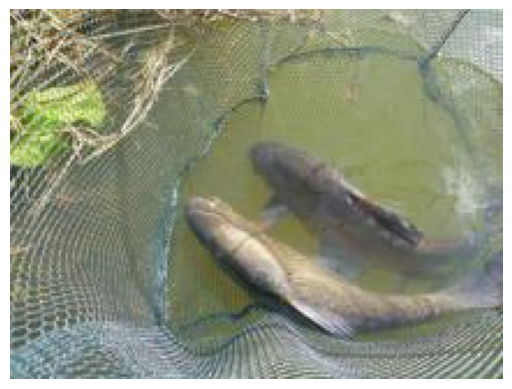

## Explore the Map-Style Contract

### Step 6\. Compare the everyday syntax with the methods beneath it

You have already used the two methods that define a map-style dataset without naming them: **len(train\_data)** used **\_\_len\_\_**, and **train\_data\[0\]** used **\_\_getitem\_\_**. This step shows that the short syntax and the direct method call produce the same result, so the contract from the chapter becomes something you can see rather than take on faith.

In [ ]:
print(len(train_data))
print(train_data.__len__())

img_a, lbl_a = train_data[5]
img_b, lbl_b = train_data.__getitem__(5)
print(lbl_a, lbl_b)


**Output:**

```
9469
9469
0 0
```

The first two lines match because **len(train\_data)** calls **train\_data.\_\_len\_\_()** for you. The last line matches because **train\_data\[5\]** calls **train\_data.\_\_getitem\_\_(5)** for you. In real code you always write **len(train\_data)** and **train\_data\[5\]**, since they read clearly and are what other Python programmers expect; calling the methods directly is shown here only to reveal what the familiar syntax does underneath.

> **Note:** Indexes start at 0, so **train\_data\[5\]** is the sixth sample. The first several samples all belong to class 0 (tench), because the dataset builds its sample list one class folder at a time in sorted order, so the earliest indices are the first class. That is why the label here is again **0**.

## Load and Compare the Splits

### Step 7\. Load the validation split

Load the held-out portion of the data. You load it exactly as you loaded the training split, changing only the value of **split**. Imagenette names its two splits **"train"** and **"val"**; the validation split is the data you use to evaluate a model on examples it did not learn from.

> **Warning:** Imagenette has no **"test"** split. Writing **split="test"** raises an error, because that name does not exist for this dataset. Use **"val"** for the held-out data.


In [ ]:
val_data = Imagenette(root="data", split="val", size="160px", download=True)

print(len(train_data))
print(len(val_data))


**Output:**

```
9469
3925
```

The training split has 9,469 images and the validation split has 3,925, which is roughly a 70/30 division. The training split is larger because a model benefits from seeing as many examples as possible while it learns, and a few thousand held-out images are enough to estimate how well it does.

### Step 8\. Compare the label balance of the two splits

Check that the held-out split resembles the training split. A fair evaluation needs the validation split to cover the same classes in similar proportion, so you count how many samples fall into each label in each split. Python's **Counter** builds the tally, and sorting it makes the ten classes easy to read in order.

> **Note:** This cell reads every image in both splits to count the labels, so it may take a minute or two to finish. The wait is itself a small lesson: **\_\_getitem\_\_** loads a sample from disk each time it is called, so touching all 13,394 samples does real work. This is expected, not a hang.


In [ ]:
from collections import Counter

train_label_counts = Counter(label for _, label in train_data)
val_label_counts = Counter(label for _, label in val_data)

print(sorted(train_label_counts.items()))
print(sorted(val_label_counts.items()))


**Sample Output**

```
[(0, 963), (1, 955), (2, 993), (3, 858), (4, 941), (5, 956), (6, 961), (7, 931), (8, 951), (9, 960)]
[(0, 387), (1, 395), (2, 357), (3, 386), (4, 409), (5, 394), (6, 389), (7, 419), (8, 399), (9, 390)]
```

Each split spreads its images fairly evenly across the ten classes, with close to 950 (roughly 10% of the training total) per class in training and close to 390 (also roughly 10% of the validation total) per class in validation. No class dominates and none is missing, so a score measured on the validation split reflects the model's ability across all ten classes rather than only the common ones.

## Cleanup

This lab does not create anything that must be torn down, and part of what it produces may be kept. There are no processes to stop and no services to remove.

**The data/ directory** holds the downloaded Imagenette files. On a local machine, keeping it means the next chapter's load is instant instead of downloading again. If you need to reclaim disk space, you may delete **data/imagenette2-160/**, but the dataset will download again the next time you load it.  
>   
On Google Colab the runtime is temporary. When your Colab session ends, the **data/** directory and the loaded **train\_data** and **val\_data** objects are cleared. This is expected. In the next chapter you simply re-run the setup cells, which download the data again for the new session.

## Summary

You loaded a real dataset and worked with it through the same small interface every PyTorch dataset exposes. You confirmed its length with **len()**, read its class names from the **classes** attribute, retrieved individual samples by index, and saw that each sample is a PIL image paired with an integer label that maps into the class list. By calling **\_\_len\_\_** and **\_\_getitem\_\_** directly, you saw the map-style contract in action rather than in theory. You then loaded the validation split and confirmed that it is comparable to the training split in size proportion and class balance.

The environment you finish with carries forward: **train\_data** is the loaded Imagenette training split, still made of variable-sized PIL images that are not yet tensors, and **val\_data** is its held-out counterpart. In the next chapter you wrap **train\_data** in a DataLoader, which uses the exact length-and-index contract you exercised here to gather these samples into batches and shuffle their order.  

